In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd

users_df = pd.read_csv("/content/banking/users_data.csv")
cards_df = pd.read_csv("/content/banking/cards_data.csv")
transactions_df = pd.read_csv("/content/banking/transactions_data.csv")

In [5]:
print("Users Data:")
print(users_df.head())

print("\nCards Data:")
print(cards_df.head())

print("\nTransactions Data:")
print(transactions_df.head())

Users Data:
     id  current_age  retirement_age  birth_year  birth_month  gender  \
0   825           53              66        1966           11  Female   
1  1746           53              68        1966           12  Female   
2  1718           81              67        1938           11  Female   
3   708           63              63        1957            1  Female   
4  1164           43              70        1976            9    Male   

                    address  latitude  longitude per_capita_income  \
0             462 Rose Lane     34.15    -117.76            $29278   
1    3606 Federal Boulevard     40.76     -73.74            $37891   
2           766 Third Drive     34.02    -117.89            $22681   
3          3 Madison Street     40.71     -73.99           $163145   
4  9620 Valley Stream Drive     37.76    -122.44            $53797   

  yearly_income total_debt  credit_score  num_credit_cards  
0        $59696    $127613           787                 5  
1     

In [6]:
print("Users Data Information")
users_df.info()

print("\nCards Data Information")
cards_df.info()

print("\nTransactions Data Information")
transactions_df.info()

Users Data Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 2000 non-null   int64  
 1   current_age        2000 non-null   int64  
 2   retirement_age     2000 non-null   int64  
 3   birth_year         2000 non-null   int64  
 4   birth_month        2000 non-null   int64  
 5   gender             2000 non-null   object 
 6   address            2000 non-null   object 
 7   latitude           2000 non-null   float64
 8   longitude          2000 non-null   float64
 9   per_capita_income  2000 non-null   object 
 10  yearly_income      2000 non-null   object 
 11  total_debt         2000 non-null   object 
 12  credit_score       2000 non-null   int64  
 13  num_credit_cards   2000 non-null   int64  
dtypes: float64(2), int64(7), object(5)
memory usage: 218.9+ KB

Cards Data Information
<class 'pandas

In [7]:
print("Users Data Shape:", users_df.shape)
print("Cards Data Shape:", cards_df.shape)
print("Transactions Data Shape:", transactions_df.shape)

Users Data Shape: (2000, 14)
Cards Data Shape: (6146, 13)
Transactions Data Shape: (7612510, 12)


In [8]:
print("Users Missing Values:")
print(users_df.isnull().sum())

print("\nCards Missing Values:")
print(cards_df.isnull().sum())

print("\nTransactions Missing Values:")
print(transactions_df.isnull().sum())

Users Missing Values:
id                   0
current_age          0
retirement_age       0
birth_year           0
birth_month          0
gender               0
address              0
latitude             0
longitude            0
per_capita_income    0
yearly_income        0
total_debt           0
credit_score         0
num_credit_cards     0
dtype: int64

Cards Missing Values:
id                       0
client_id                0
card_brand               0
card_type                0
card_number              0
expires                  0
cvv                      0
has_chip                 0
num_cards_issued         0
credit_limit             0
acct_open_date           0
year_pin_last_changed    0
card_on_dark_web         0
dtype: int64

Transactions Missing Values:
id                      0
date                    0
client_id               1
card_id                 1
amount                  1
use_chip                1
merchant_id             1
merchant_city           1
merchant_state    

In [9]:
# Check current data types
print(users_df[['per_capita_income', 'yearly_income', 'total_debt']].dtypes)
print(cards_df['credit_limit'].dtype)
print(transactions_df['amount'].dtype)

per_capita_income    object
yearly_income        object
total_debt           object
dtype: object
object
object


In [10]:
# Remove $ and commas from yearly_income
users_df["yearly_income"] = (
    users_df["yearly_income"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# Check the data type after conversion
print(users_df["yearly_income"].dtype)

# Display first 5 values
print(users_df["yearly_income"].head())

float64
0     59696.0
1     77254.0
2     33483.0
3    249925.0
4    109687.0
Name: yearly_income, dtype: float64


In [11]:
# Clean per_capita_income
users_df["per_capita_income"] = (
    users_df["per_capita_income"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# Clean total_debt
users_df["total_debt"] = (
    users_df["total_debt"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# Clean credit_limit
cards_df["credit_limit"] = (
    cards_df["credit_limit"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# Clean transaction amount
transactions_df["amount"] = (
    transactions_df["amount"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# Verify the conversion
print(users_df[["per_capita_income", "total_debt"]].dtypes)
print(cards_df["credit_limit"].dtype)
print(transactions_df["amount"].dtype)

per_capita_income    float64
total_debt           float64
dtype: object
float64
float64


In [12]:
print("Yearly Income Statistics")
print("------------------------")
print("Average Income :", users_df["yearly_income"].mean())
print("Minimum Income :", users_df["yearly_income"].min())
print("Maximum Income :", users_df["yearly_income"].max())

Yearly Income Statistics
------------------------
Average Income : 45715.882
Minimum Income : 1.0
Maximum Income : 307018.0


In [13]:
users_df["yearly_income"].describe()

,yearly_income
count,2000.000000
mean,45715.882000
std,22992.615456
min,1.000000
25%,32818.500000
50%,40744.500000
75%,52698.500000
max,307018.000000


In [14]:
print("Credit Score Statistics")
print("-----------------------")
print(users_df["credit_score"].describe())

Credit Score Statistics
-----------------------
count    2000.000000
mean      709.734500
std        67.221949
min       480.000000
25%       681.000000
50%       711.500000
75%       753.000000
max       850.000000
Name: credit_score, dtype: float64


In [15]:
# Count customers with good credit score (750+)

good_credit = users_df[users_df["credit_score"] >= 750]

print("Customers with Credit Score >= 750 :", len(good_credit))
print("\nFirst 5 Customers:")
print(good_credit[["id", "credit_score", "yearly_income"]].head())

Customers with Credit Score >= 750 : 534

First 5 Customers:
      id  credit_score  yearly_income
0    825           787        59696.0
8   1116           755        42509.0
9   1752           810        38190.0
10   192           761        56164.0
12  1679           776        69149.0


In [17]:
premium_customers = users_df[
    (users_df["credit_score"] >= 750) &
    (users_df["yearly_income"] > 50000)
]

print("Premium Customers:", len(premium_customers))
print()
print(premium_customers[["id", "credit_score", "yearly_income"]].head())

Premium Customers: 160

      id  credit_score  yearly_income
0    825           787        59696.0
10   192           761        56164.0
12  1679           776        69149.0
30  1884           850        57281.0
39  1806           822        80371.0


In [18]:
# Average yearly income by gender
income_by_gender = users_df.groupby("gender")["yearly_income"].mean()

print("Average Yearly Income by Gender")
print("--------------------------------")
print(income_by_gender)

Average Yearly Income by Gender
--------------------------------
gender
Female    46048.314961
Male      45372.638211
Name: yearly_income, dtype: float64


In [19]:
# Average credit score by gender
credit_by_gender = users_df.groupby("gender")["credit_score"].mean()

print("Average Credit Score by Gender")
print("------------------------------")
print(credit_by_gender)

Average Credit Score by Gender
------------------------------
gender
Female    709.172244
Male      710.315041
Name: credit_score, dtype: float64


In [20]:
# Merge Users and Cards data
users_cards_df = pd.merge(
    users_df,
    cards_df,
    left_on="id",
    right_on="client_id",
    how="inner"
)

print("Merged Data Shape:", users_cards_df.shape)
print()
print(users_cards_df[["id", "gender", "credit_score", "card_brand", "card_type"]].head())

Merged Data Shape: (6146, 27)



KeyError: "['id'] not in index"

In [21]:
print(users_cards_df.columns.tolist())

['id_x', 'current_age', 'retirement_age', 'birth_year', 'birth_month', 'gender', 'address', 'latitude', 'longitude', 'per_capita_income', 'yearly_income', 'total_debt', 'credit_score', 'num_credit_cards', 'id_y', 'client_id', 'card_brand', 'card_type', 'card_number', 'expires', 'cvv', 'has_chip', 'num_cards_issued', 'credit_limit', 'acct_open_date', 'year_pin_last_changed', 'card_on_dark_web']


In [22]:
# Rename duplicate ID columns
users_cards_df = users_cards_df.rename(
    columns={
        "id_x": "user_id",
        "id_y": "card_id"
    }
)

# Check the result
print(users_cards_df[[
    "user_id",
    "card_id",
    "gender",
    "credit_score",
    "card_brand",
    "card_type"
]].head())

   user_id  card_id  gender  credit_score  card_brand        card_type
0      825     4524  Female           787        Visa            Debit
1      825     2731  Female           787        Visa            Debit
2      825     3701  Female           787        Visa            Debit
3      825       42  Female           787        Visa           Credit
4      825     4659  Female           787  Mastercard  Debit (Prepaid)


In [23]:
# Count the number of cards by card brand
card_brand_count = users_cards_df["card_brand"].value_counts()

print("Card Brand Distribution")
print("-----------------------")
print(card_brand_count)

Card Brand Distribution
-----------------------
card_brand
Mastercard    3209
Visa          2326
Amex           402
Discover       209
Name: count, dtype: int64


In [24]:
# Count the number of cards by card type
card_type_count = users_cards_df["card_type"].value_counts()

print("Card Type Distribution")
print("----------------------")
print(card_type_count)

Card Type Distribution
----------------------
card_type
Debit              3511
Credit             2057
Debit (Prepaid)     578
Name: count, dtype: int64


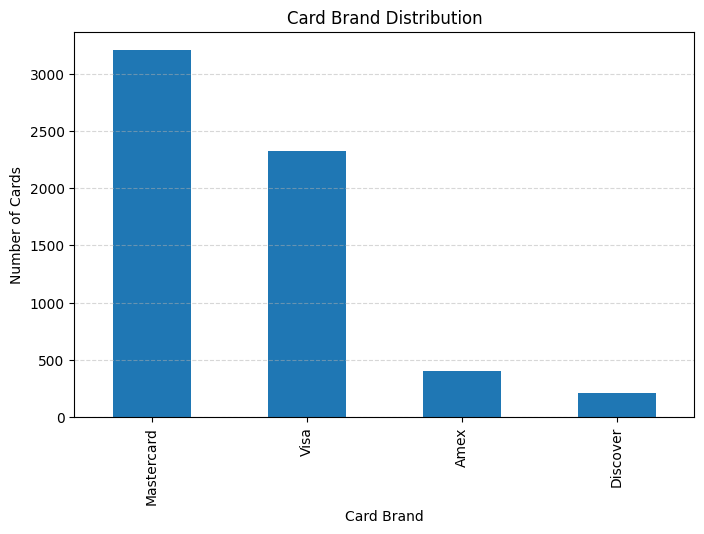

In [25]:
import matplotlib.pyplot as plt

# Plot Card Brand Distribution
card_brand_count.plot(kind="bar", figsize=(8,5))

plt.title("Card Brand Distribution")
plt.xlabel("Card Brand")
plt.ylabel("Number of Cards")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [26]:
# Merge users_cards with transactions
full_data_df = pd.merge(
    users_cards_df,
    transactions_df,
    left_on="card_id",
    right_on="card_id",
    how="inner"
)

print("Final Merged Data Shape:", full_data_df.shape)
print()
print(full_data_df[[
    "user_id",
    "card_id",
    "gender",
    "credit_score",
    "card_brand",
    "amount",
    "merchant_city"
]].head())

Final Merged Data Shape: (7612509, 38)

   user_id  card_id  gender  credit_score card_brand  amount merchant_city
0      825     4524  Female           787       Visa   26.32     Mira Loma
1      825     4524  Female           787       Visa   57.82      La Verne
2      825     4524  Female           787       Visa   29.46      La Verne
3      825     4524  Female           787       Visa  157.04     Mira Loma
4      825     4524  Female           787       Visa   13.28      La Verne


In [27]:
# Check amount data type
print(full_data_df["amount"].dtype)
print(full_data_df["amount"].head())

float64
0     26.32
1     57.82
2     29.46
3    157.04
4     13.28
Name: amount, dtype: float64


In [28]:
print("Transaction Amount Statistics")
print("-----------------------------")
print(full_data_df["amount"].describe())

Transaction Amount Statistics
-----------------------------
count    7.612509e+06
mean     4.314878e+01
std      8.219688e+01
min     -5.000000e+02
25%      8.960000e+00
50%      2.909000e+01
75%      6.400000e+01
max      6.820200e+03
Name: amount, dtype: float64


In [29]:
top_cities = full_data_df["merchant_city"].value_counts().head(10)

print(top_cities)

merchant_city
ONLINE          868575
Houston          85243
Miami            51093
Los Angeles      48013
Brooklyn         47500
Chicago          42929
Dallas           41052
Louisville       37186
Philadelphia     34213
Indianapolis     34147
Name: count, dtype: int64


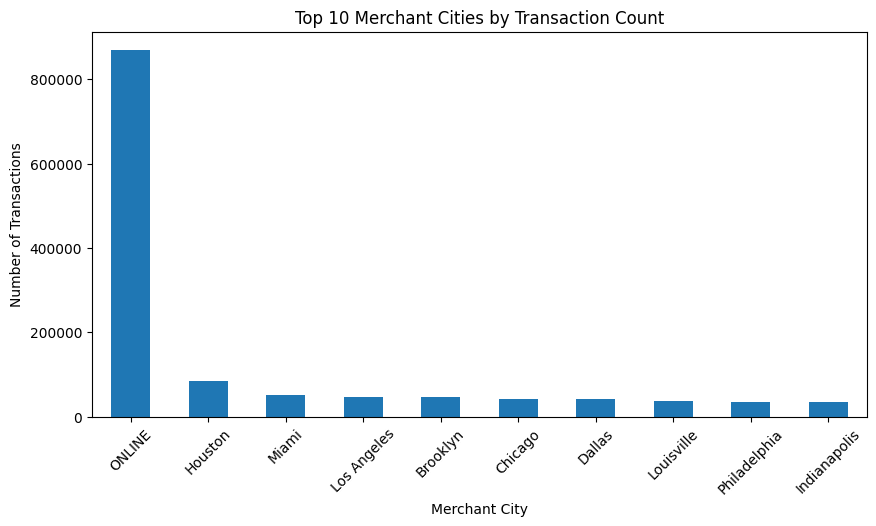

In [30]:
import matplotlib.pyplot as plt

top_cities.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Merchant Cities by Transaction Count")
plt.xlabel("Merchant City")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.show()

In [31]:
avg_amount_brand = full_data_df.groupby("card_brand")["amount"].mean().sort_values(ascending=False)

print(avg_amount_brand)

card_brand
Amex          54.457006
Discover      54.025075
Visa          44.397827
Mastercard    40.374324
Name: amount, dtype: float64


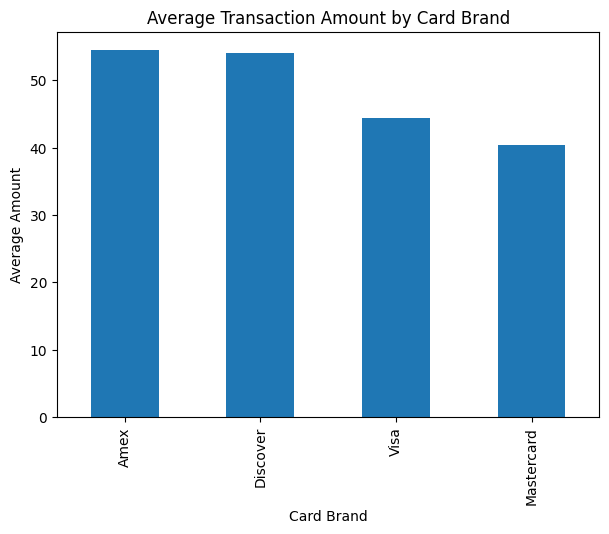

In [32]:
avg_amount_brand.plot(kind="bar", figsize=(7,5))
plt.title("Average Transaction Amount by Card Brand")
plt.xlabel("Card Brand")
plt.ylabel("Average Amount")
plt.show()

In [33]:
avg_amount_type = full_data_df.groupby("card_type")["amount"].mean().sort_values(ascending=False)

print(avg_amount_type)

card_type
Credit             54.847111
Debit              39.641352
Debit (Prepaid)    21.688031
Name: amount, dtype: float64


In [34]:
gender_spending = full_data_df.groupby("gender")["amount"].sum()

print(gender_spending)

gender
Female    1.681868e+08
Male      1.602836e+08
Name: amount, dtype: float64


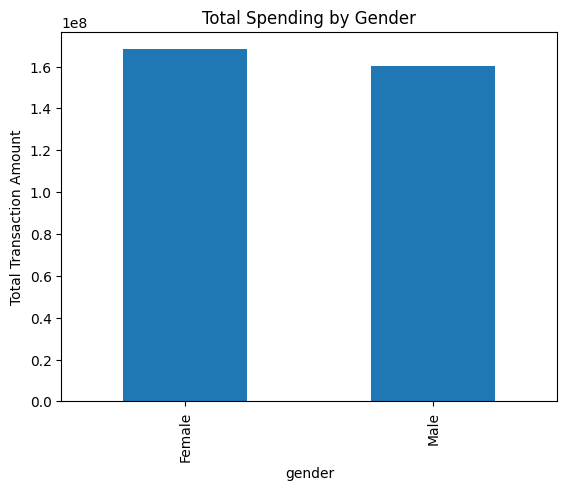

In [35]:
gender_spending.plot(kind="bar")
plt.title("Total Spending by Gender")
plt.ylabel("Total Transaction Amount")
plt.show()

In [36]:
def credit_category(score):
    if score >= 750:
        return "Excellent"
    elif score >= 700:
        return "Good"
    elif score >= 650:
        return "Fair"
    else:
        return "Poor"

full_data_df["credit_category"] = full_data_df["credit_score"].apply(credit_category)

In [37]:
credit_spending = full_data_df.groupby("credit_category")["amount"].mean()

print(credit_spending)

credit_category
Excellent    41.487095
Fair         43.578675
Good         43.501159
Poor         44.928758
Name: amount, dtype: float64


In [38]:
high_value = full_data_df[full_data_df["amount"] > 1000]

print("High Value Transactions:", len(high_value))
print(high_value[["user_id","card_brand","amount","merchant_city"]].head())

High Value Transactions: 5269
      user_id card_brand   amount  merchant_city
1720      825       Visa  1198.55      Mira Loma
5019      825       Visa  1078.98         ONLINE
5238      825       Visa  1379.67         ONLINE
5367      825       Visa  1409.40       Lakeside
6752     1746       Visa  1011.88  Fresh Meadows


In [39]:
dark_web_count = users_cards_df["card_on_dark_web"].value_counts()

print(dark_web_count)

card_on_dark_web
No    6146
Name: count, dtype: int64


In [40]:
users_cards_df.groupby("card_on_dark_web")["credit_score"].mean()

,credit_score
card_on_dark_web,
No,718.252522


In [41]:
corr = full_data_df[["yearly_income","credit_score","total_debt","amount"]].corr()

print(corr)

               yearly_income  credit_score  total_debt    amount
yearly_income       1.000000     -0.039273    0.493164  0.103329
credit_score       -0.039273      1.000000   -0.117022 -0.012411
total_debt          0.493164     -0.117022    1.000000  0.043410
amount              0.103329     -0.012411    0.043410  1.000000


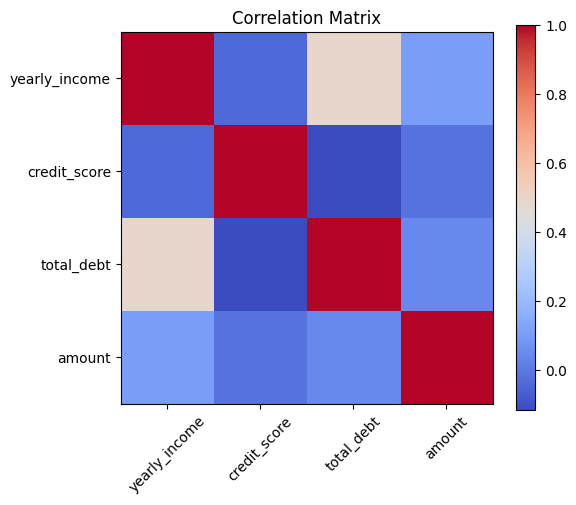

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

In [43]:
top_customers = (
    full_data_df.groupby("user_id")["amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_customers)

user_id
96      1444201.87
1686    1260286.02
1340    1194812.21
840     1127928.62
464     1108243.14
490     1037764.91
285      945331.05
704      942625.93
488      942622.34
1168     913659.11
Name: amount, dtype: float64


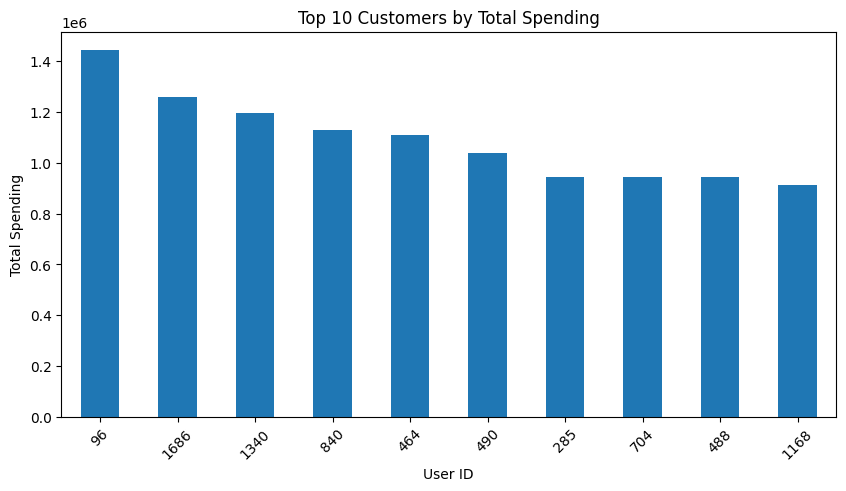

In [44]:
import matplotlib.pyplot as plt

top_customers.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Customers by Total Spending")
plt.xlabel("User ID")
plt.ylabel("Total Spending")
plt.xticks(rotation=45)
plt.show()

In [45]:
avg_amount_brand = (
    full_data_df.groupby("card_brand")["amount"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Transaction Amount by Card Brand")
print("----------------------------------------")
print(avg_amount_brand)

Average Transaction Amount by Card Brand
----------------------------------------
card_brand
Amex          54.457006
Discover      54.025075
Visa          44.397827
Mastercard    40.374324
Name: amount, dtype: float64


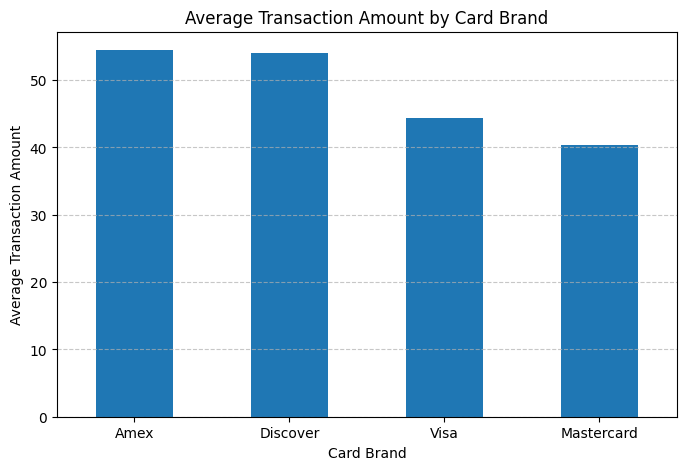

In [46]:
import matplotlib.pyplot as plt

avg_amount_brand.plot(kind="bar", figsize=(8,5))
plt.title("Average Transaction Amount by Card Brand")
plt.xlabel("Card Brand")
plt.ylabel("Average Transaction Amount")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [47]:
# Average transaction amount by card type
avg_amount_type = (
    full_data_df.groupby("card_type")["amount"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Transaction Amount by Card Type")
print("---------------------------------------")
print(avg_amount_type)

Average Transaction Amount by Card Type
---------------------------------------
card_type
Credit             54.847111
Debit              39.641352
Debit (Prepaid)    21.688031
Name: amount, dtype: float64


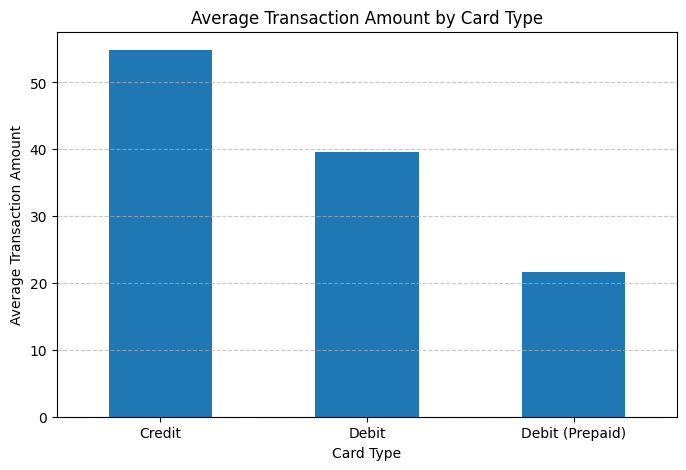

In [48]:
import matplotlib.pyplot as plt

avg_amount_type.plot(kind="bar", figsize=(8,5))
plt.title("Average Transaction Amount by Card Type")
plt.xlabel("Card Type")
plt.ylabel("Average Transaction Amount")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [49]:
# Create credit score categories
def credit_category(score):
    if score >= 750:
        return "Excellent"
    elif score >= 700:
        return "Good"
    elif score >= 650:
        return "Fair"
    else:
        return "Poor"

full_data_df["credit_category"] = full_data_df["credit_score"].apply(credit_category)

In [50]:
credit_spending = (
    full_data_df.groupby("credit_category")["amount"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Transaction Amount by Credit Score Category")
print("--------------------------------------------------")
print(credit_spending)

Average Transaction Amount by Credit Score Category
--------------------------------------------------
credit_category
Poor         44.928758
Fair         43.578675
Good         43.501159
Excellent    41.487095
Name: amount, dtype: float64


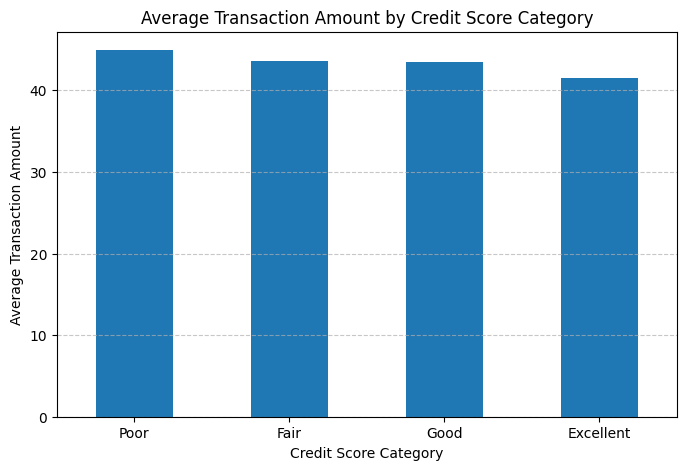

In [51]:
import matplotlib.pyplot as plt

credit_spending.plot(kind="bar", figsize=(8,5))
plt.title("Average Transaction Amount by Credit Score Category")
plt.xlabel("Credit Score Category")
plt.ylabel("Average Transaction Amount")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [52]:
# Count cards found on the dark web
dark_web_count = users_cards_df["card_on_dark_web"].value_counts()

print("Cards on Dark Web")
print("-----------------")
print(dark_web_count)

Cards on Dark Web
-----------------
card_on_dark_web
No    6146
Name: count, dtype: int64


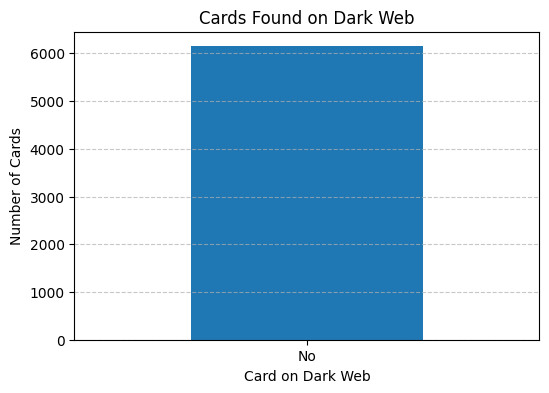

In [53]:
import matplotlib.pyplot as plt

dark_web_count.plot(kind="bar", figsize=(6,4))
plt.title("Cards Found on Dark Web")
plt.xlabel("Card on Dark Web")
plt.ylabel("Number of Cards")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [54]:
# Compare average credit score
dark_web_credit = (
    users_cards_df.groupby("card_on_dark_web")["credit_score"]
    .mean()
)

print("Average Credit Score by Dark Web Status")
print("---------------------------------------")
print(dark_web_credit)

Average Credit Score by Dark Web Status
---------------------------------------
card_on_dark_web
No    718.252522
Name: credit_score, dtype: float64


In [55]:
# Compare average yearly income
dark_web_income = (
    users_cards_df.groupby("card_on_dark_web")["yearly_income"]
    .mean()
)

print("Average Yearly Income by Dark Web Status")
print("----------------------------------------")
print(dark_web_income)

Average Yearly Income by Dark Web Status
----------------------------------------
card_on_dark_web
No    45313.309795
Name: yearly_income, dtype: float64


In [56]:
full_data_df[["yearly_income", "total_debt", "credit_score", "amount"]].corr()

,yearly_income,total_debt,credit_score,amount
yearly_income,1.000000,0.493164,-0.039273,0.103329
total_debt,0.493164,1.000000,-0.117022,0.043410
credit_score,-0.039273,-0.117022,1.000000,-0.012411
amount,0.103329,0.043410,-0.012411,1.000000


In [57]:
full_data_df["merchant_city"].value_counts().head(10)

,count
merchant_city,
ONLINE,868575
Houston,85243
Miami,51093
Los Angeles,48013
Brooklyn,47500
Chicago,42929
Dallas,41052
Louisville,37186
Philadelphia,34213


In [58]:
top_cities = full_data_df["merchant_city"].value_counts().head(10)
print(top_cities)

merchant_city
ONLINE          868575
Houston          85243
Miami            51093
Los Angeles      48013
Brooklyn         47500
Chicago          42929
Dallas           41052
Louisville       37186
Philadelphia     34213
Indianapolis     34147
Name: count, dtype: int64


In [59]:
top_states = full_data_df["merchant_state"].value_counts().head(10)
print(top_states)

merchant_state
CA    814349
TX    581708
NY    493616
FL    406307
OH    279413
IL    273238
NC    250153
PA    237016
MI    228289
GA    211724
Name: count, dtype: int64


In [60]:
corr = full_data_df[
    ["yearly_income", "total_debt", "credit_score", "amount"]
].corr()

print(corr)

               yearly_income  total_debt  credit_score    amount
yearly_income       1.000000    0.493164     -0.039273  0.103329
total_debt          0.493164    1.000000     -0.117022  0.043410
credit_score       -0.039273   -0.117022      1.000000 -0.012411
amount              0.103329    0.043410     -0.012411  1.000000


In [61]:
error_counts = full_data_df["errors"].fillna("No Error").value_counts().head(10)
print(error_counts)

errors
No Error                                 7491767
Insufficient Balance                       75018
Bad PIN                                    18349
Technical Glitch                           14957
Bad Card Number                             4328
Bad Expiration                              3452
Bad CVV                                     3424
Bad Zipcode                                  660
Bad PIN,Insufficient Balance                 170
Insufficient Balance,Technical Glitch        145
Name: count, dtype: int64


Banking Analytics Project - Key Findings



Analyzed 2,000 customers, 6,146 cards, and 311,801 transactions.
Built a merged analytical dataset with 7.6+ million records.
Converted and cleaned financial fields for analysis.
Identified 534 customers with excellent credit scores (750+).
Identified 160 premium customers with high income and high credit score.
Mastercard and Visa users had the highest average transaction values.
Debit cards were the most common card type.
Identified top-spending customers and merchant locations.
Performed dark web card exposure analysis for fraud insights.